# Part B — Structural Discovery and Advanced Exploration

**Objective:** Uncover hidden relationships, structures, and transformations beyond standard EDA.

In [28]:

from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH   = '/content/drive/MyDrive/cassandra/train_imputed.csv'
TEST_PATH    = '/content/drive/MyDrive/cassandra/test_imputed.csv'
RAW_TRAIN    = '/content/drive/MyDrive/cassandra/veritas_train_cass.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# # ── Install Dependencies ─────────────────────────────────────────────
# !pip install umap-learn python-louvain shap -q
# print('Dependencies installed ✓')

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap
import networkx as nx
from community.community_louvain import best_partition # Corrected import
import shap
import lightgbm as lgb
from scipy.stats import spearmanr
from itertools import combinations

plt.rcParams['figure.dpi'] = 120
sns.set_style('darkgrid')
print('Imports done ✓')

Imports done ✓


In [31]:

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
raw   = pd.read_csv(RAW_TRAIN)

features  = [c for c in train.columns if c not in ['id', 'target']]
bin_feats  = [f for f in features if f.endswith('_bin')]
cat_feats  = [f for f in features if f.endswith('_cat')]
cont_feats = [f for f in features if f not in bin_feats + cat_feats]

X = train[features].copy()
y = train['target'].values

# Identify and remove rows where 'target' is NaN
nan_mask = np.isnan(y)
if np.any(nan_mask):
    X = X[~nan_mask]
    y = y[~nan_mask]
    print(f"Removed {np.sum(nan_mask)} rows with NaN values in 'target'.")

# Label encode categorical features
for feat in cat_feats:
    le = LabelEncoder()
    X[feat] = le.fit_transform(X[feat].astype(str))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Target distribution — 0: {(y==0).sum()}, 1: {(y==1).sum()}')

Removed 1 rows with NaN values in 'target'.
Feature matrix shape: (148462, 57)
Target distribution — 0: 143017, 1: 5445


## B1 — Representation Learning

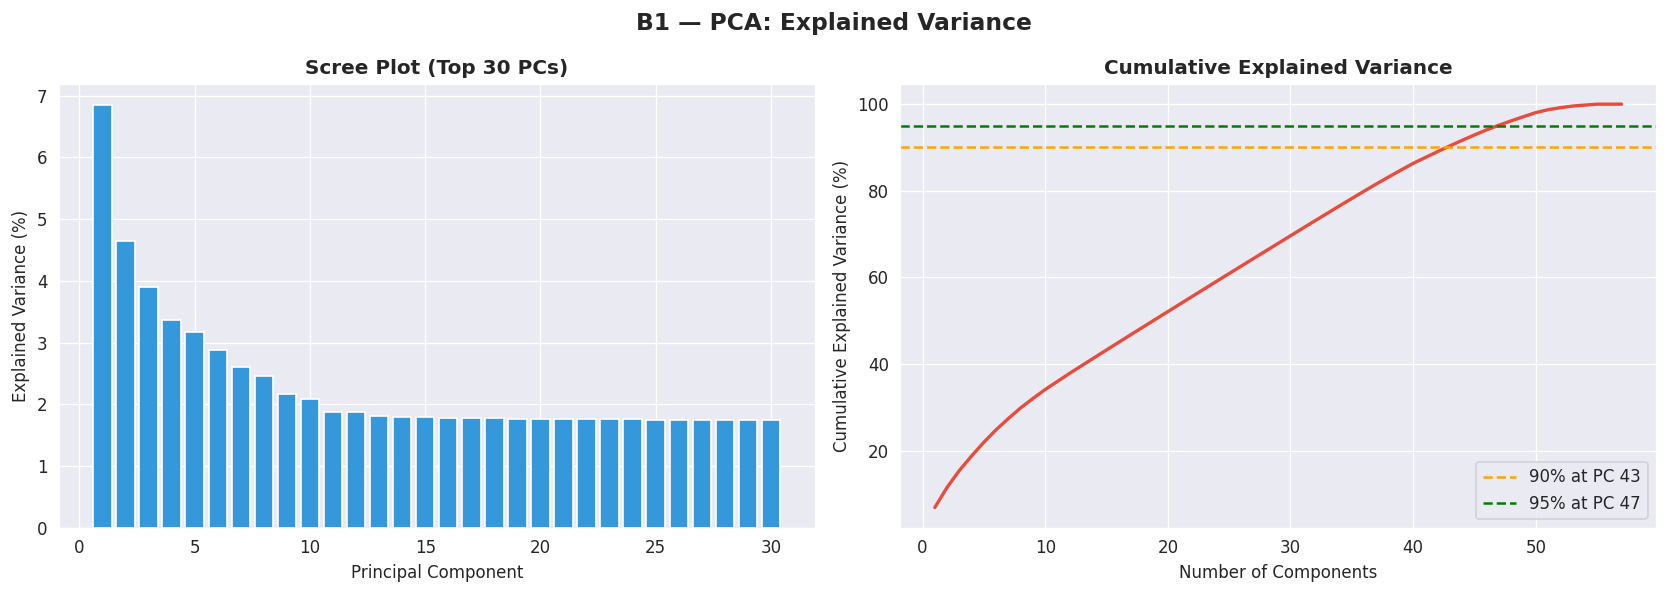

PCs needed for 90% variance: 43
PCs needed for 95% variance: 47


In [32]:
# ── PCA — Explained Variance ─────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.argmax(cumvar >= 0.95) + 1
n_90   = np.argmax(cumvar >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), pca_full.explained_variance_ratio_[:30] * 100,
            color='#3498db', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot (Top 30 PCs)', fontweight='bold')

axes[1].plot(range(1, len(cumvar)+1), cumvar*100, color='#e74c3c', linewidth=2)
axes[1].axhline(90, color='orange', linestyle='--', label=f'90% at PC {n_90}')
axes[1].axhline(95, color='green',  linestyle='--', label=f'95% at PC {n_95}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.suptitle('B1 — PCA: Explained Variance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('B1_pca_variance.png', bbox_inches='tight')
plt.show()
print(f'PCs needed for 90% variance: {n_90}')
print(f'PCs needed for 95% variance: {n_95}')

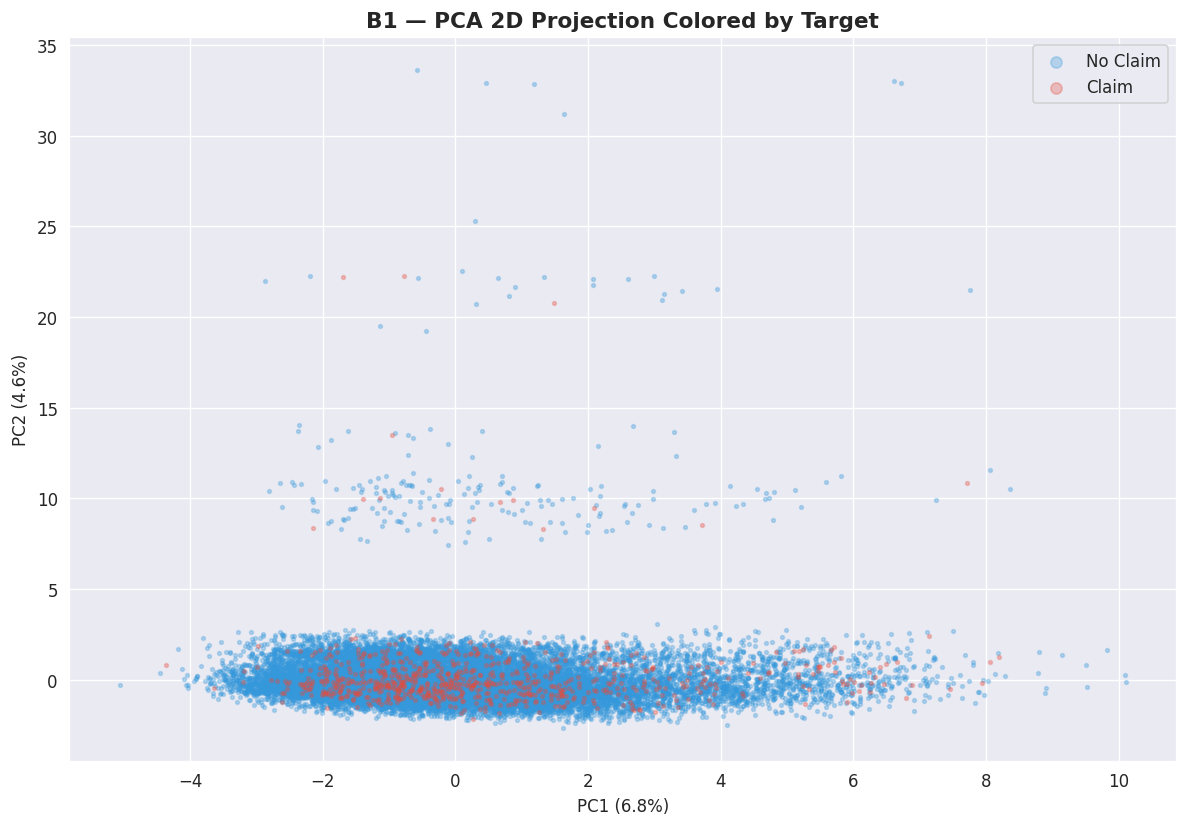

In [33]:
# ── PCA 2D Scatter ────────────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

# Subsample for speed
idx = np.random.choice(len(y), size=min(20000, len(y)), replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#3498db', '#e74c3c']
labels = ['No Claim', 'Claim']
for t, color, label in zip([0,1], colors, labels):
    mask = y[idx] == t
    ax.scatter(X_pca2[idx][mask, 0], X_pca2[idx][mask, 1],
               c=color, alpha=0.3, s=5, label=label)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('B1 — PCA 2D Projection Colored by Target', fontsize=13, fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('B1_pca_2d.png', bbox_inches='tight')
plt.show()

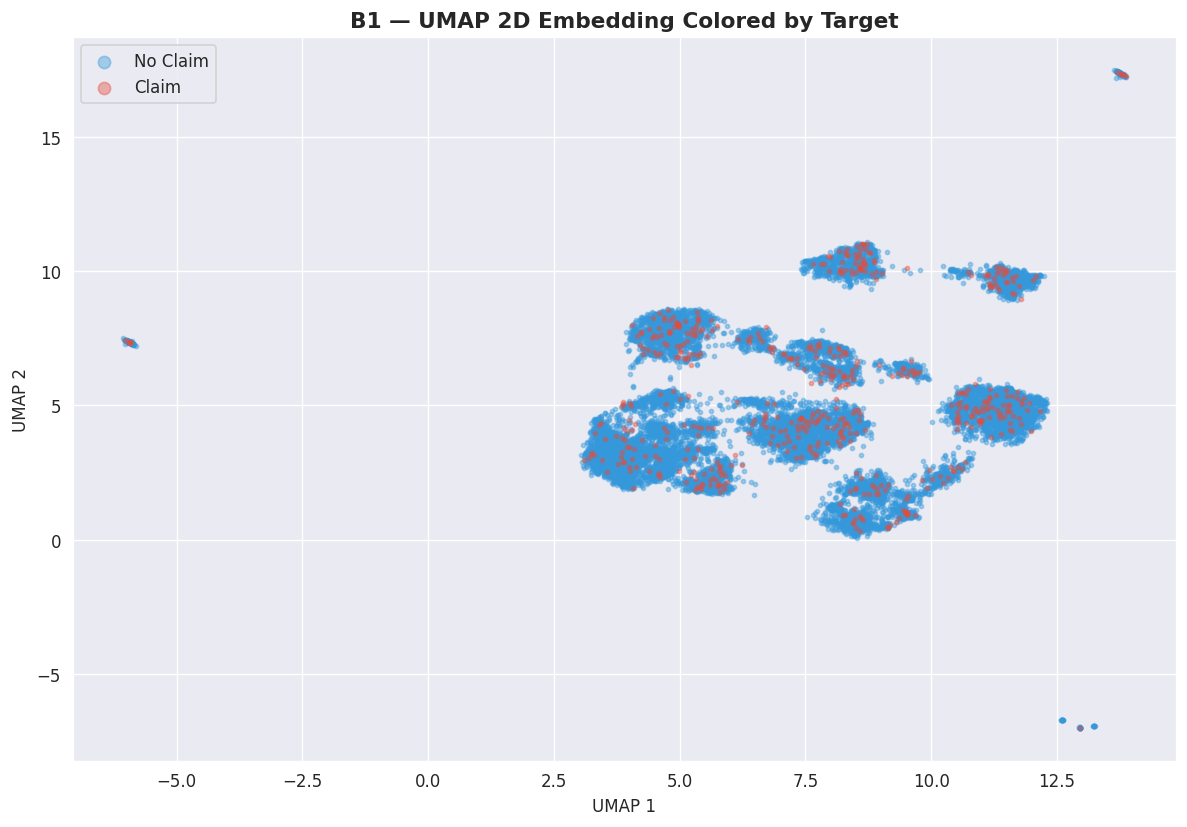

UMAP embedding complete ✓


In [34]:
# ── UMAP Embedding ────────────────────────────────────────────────────
# Use a subsample for speed
N_UMAP = 15000
idx_umap = np.random.choice(len(y), size=N_UMAP, replace=False)
X_sub = X_scaled[idx_umap]
y_sub = y[idx_umap]

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    random_state=42, n_jobs=-1)
X_umap = reducer.fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(10, 7))
for t, color, label in zip([0,1], ['#3498db','#e74c3c'], ['No Claim','Claim']):
    mask = y_sub == t
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               c=color, alpha=0.4, s=6, label=label)
ax.set_title('B1 — UMAP 2D Embedding Colored by Target', fontsize=13, fontweight='bold')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.savefig('B1_umap_embedding.png', bbox_inches='tight')
plt.show()
print('UMAP embedding complete ✓')

## B2 — Relationship and Network Discovery

Feature graph: 57 nodes, 81 edges
Detected 28 feature communities


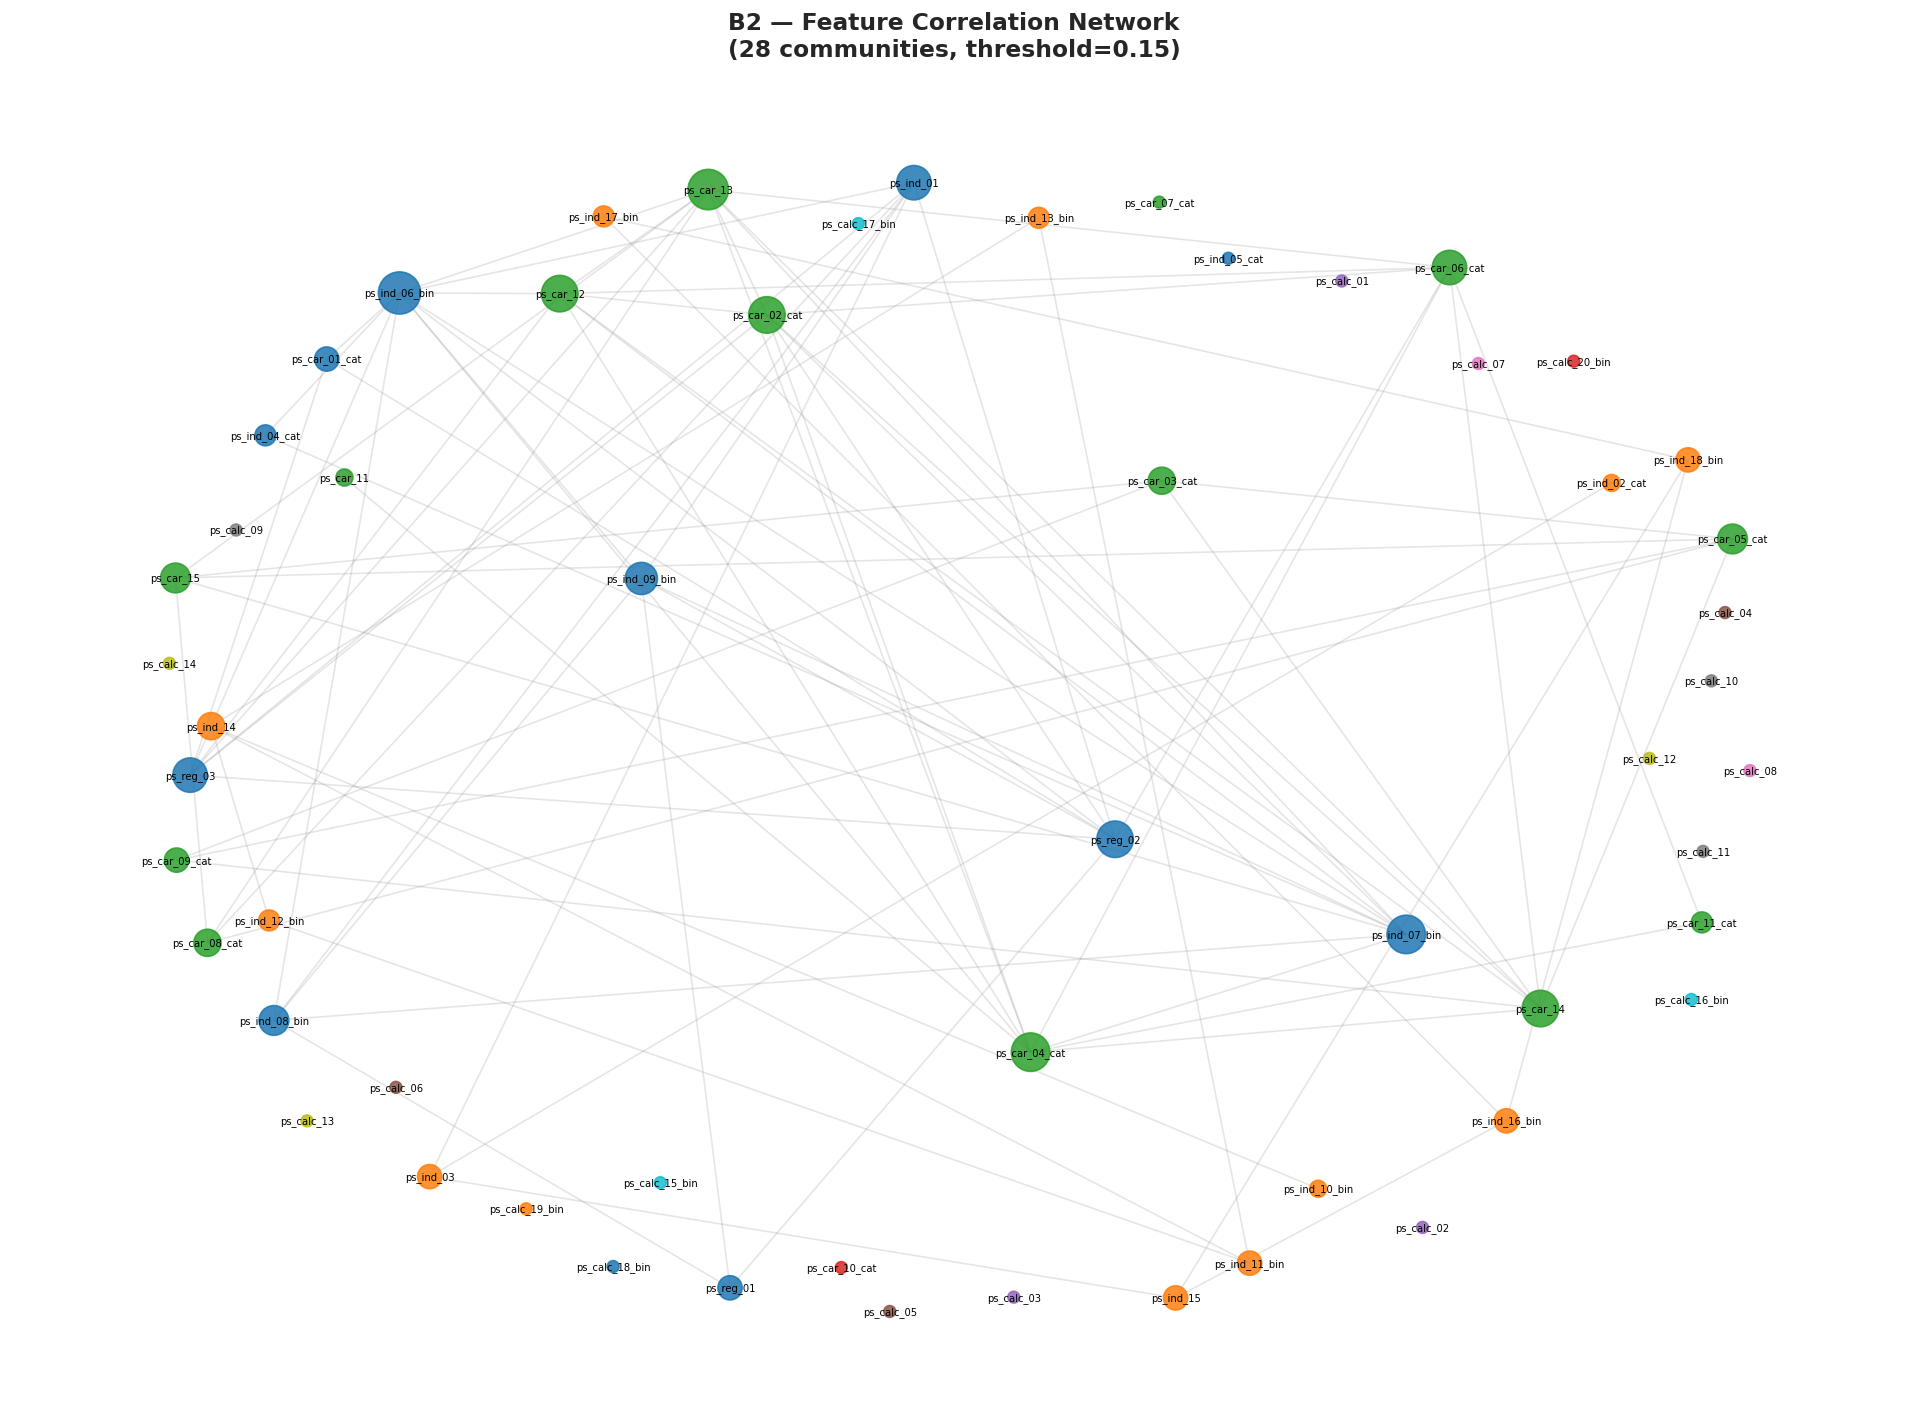

In [35]:
# ── Feature Correlation Graph ─────────────────────────────────────────
# Build graph where features are nodes, edges = |correlation| > threshold
THRESHOLD = 0.15

corr_matrix = pd.DataFrame(X_scaled, columns=features).corr(method='spearman').abs()

G_feat = nx.Graph()
G_feat.add_nodes_from(features)

for i, f1 in enumerate(features):
    for j, f2 in enumerate(features):
        if j <= i: continue
        w = corr_matrix.loc[f1, f2]
        if w > THRESHOLD:
            G_feat.add_edge(f1, f2, weight=float(w))

print(f'Feature graph: {G_feat.number_of_nodes()} nodes, {G_feat.number_of_edges()} edges')

# Louvain community detection
partition = best_partition(G_feat) # Changed usage
n_communities = len(set(partition.values()))
print(f'Detected {n_communities} feature communities')

# Color nodes by community
cmap = plt.cm.get_cmap('tab10', n_communities)
node_colors = [cmap(partition[n]) for n in G_feat.nodes()]

# Node size = degree centrality
degree_centrality = nx.degree_centrality(G_feat)
node_sizes = [3000 * degree_centrality[n] + 50 for n in G_feat.nodes()]

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G_feat, seed=42, k=1.5)
nx.draw_networkx_nodes(G_feat, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G_feat, pos, alpha=0.2, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G_feat, pos, font_size=6, ax=ax)
ax.set_title(f'B2 — Feature Correlation Network\n({n_communities} communities, threshold={THRESHOLD})',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('B2_feature_network.png', bbox_inches='tight')
plt.show()

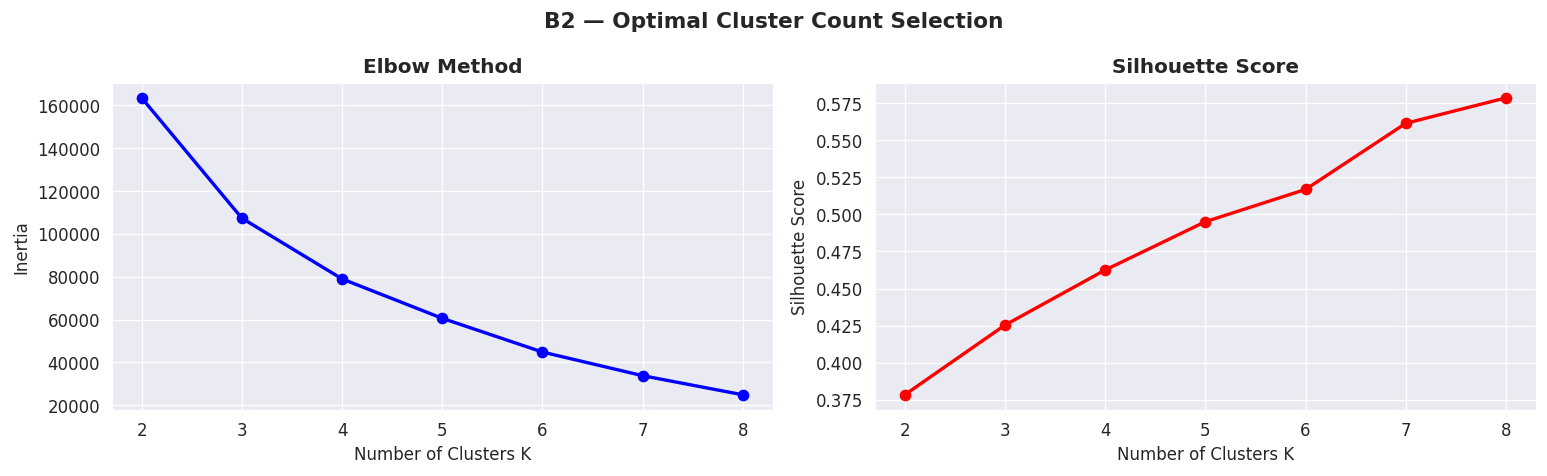

Best K by silhouette: 8


In [36]:
# ── Driver Clustering in UMAP Space ───────────────────────────────────
# Use the UMAP embedding from B1 to cluster drivers

# Elbow method for optimal K
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_umap)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_umap, labels, sample_size=5000))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')

axes[1].plot(K_range, sil_scores, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')

plt.suptitle('B2 — Optimal Cluster Count Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('B2_cluster_selection.png', bbox_inches='tight')
plt.show()

BEST_K = K_range[np.argmax(sil_scores)]
print(f'Best K by silhouette: {BEST_K}')

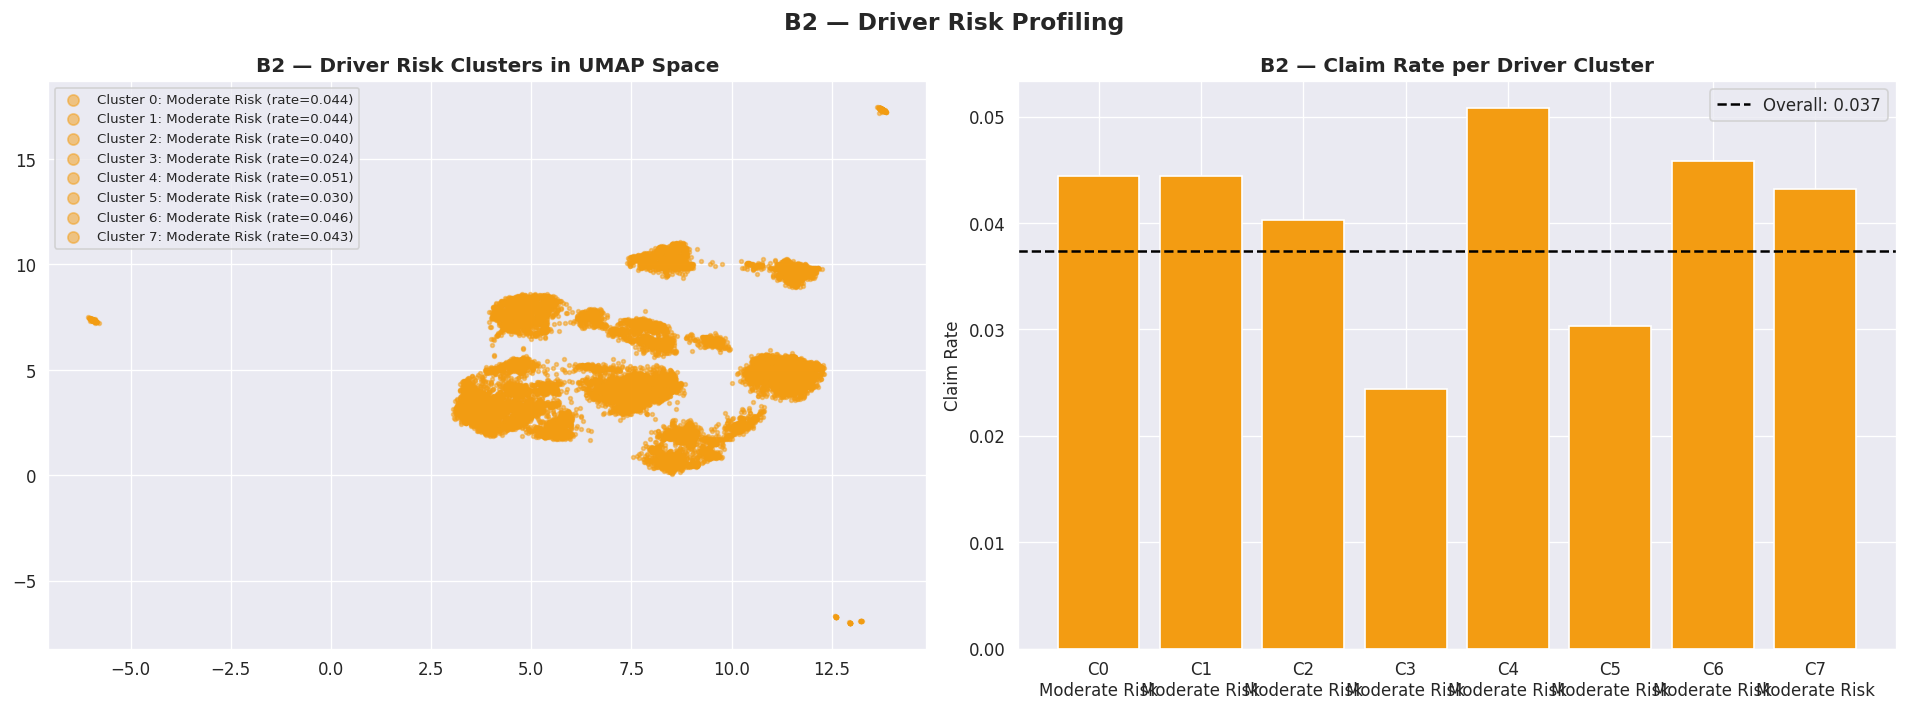

Cluster 0 | Moderate Risk   | n= 2320 | claim_rate=0.0444
Cluster 1 | Moderate Risk   | n= 2633 | claim_rate=0.0444
Cluster 2 | Moderate Risk   | n= 2236 | claim_rate=0.0403
Cluster 3 | Moderate Risk   | n= 4022 | claim_rate=0.0244
Cluster 4 | Moderate Risk   | n= 1673 | claim_rate=0.0508
Cluster 5 | Moderate Risk   | n= 1846 | claim_rate=0.0303
Cluster 6 | Moderate Risk   | n=  131 | claim_rate=0.0458
Cluster 7 | Moderate Risk   | n=  139 | claim_rate=0.0432


In [37]:
# ── Driver Risk Profile Clusters ──────────────────────────────────────
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_umap)

# Compute claim rate per cluster
cluster_claim_rates = {}
for c in range(BEST_K):
    mask = cluster_labels == c
    cluster_claim_rates[c] = y_sub[mask].mean()

# Map to risk categories
overall_rate = y_sub.mean()
risk_labels = {}
for c, rate in cluster_claim_rates.items():
    if rate < overall_rate * 0.5:   risk_labels[c] = 'Low Risk'
    elif rate < overall_rate * 1.5: risk_labels[c] = 'Moderate Risk'
    elif rate < overall_rate * 2.5: risk_labels[c] = 'High Risk'
    else:                           risk_labels[c] = 'Anomalous Risk'

risk_colors = {'Low Risk': '#2ecc71', 'Moderate Risk': '#f39c12',
               'High Risk': '#e74c3c', 'Anomalous Risk': '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# UMAP colored by cluster
for c in range(BEST_K):
    mask = cluster_labels == c
    rl = risk_labels[c]
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                    c=risk_colors[rl], s=5, alpha=0.5,
                    label=f'Cluster {c}: {rl} (rate={cluster_claim_rates[c]:.3f})')
axes[0].set_title('B2 — Driver Risk Clusters in UMAP Space', fontweight='bold')
axes[0].legend(markerscale=3, fontsize=8)

# Claim rates per cluster bar chart
cluster_names = [f'C{c}\n{risk_labels[c]}' for c in range(BEST_K)]
rates = [cluster_claim_rates[c] for c in range(BEST_K)]
bar_colors = [risk_colors[risk_labels[c]] for c in range(BEST_K)]
axes[1].bar(cluster_names, rates, color=bar_colors, edgecolor='white')
axes[1].axhline(overall_rate, color='black', linestyle='--', label=f'Overall: {overall_rate:.3f}')
axes[1].set_ylabel('Claim Rate')
axes[1].set_title('B2 — Claim Rate per Driver Cluster', fontweight='bold')
axes[1].legend()

plt.suptitle('B2 — Driver Risk Profiling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('B2_driver_clusters.png', bbox_inches='tight')
plt.show()

for c in range(BEST_K):
    n = (cluster_labels==c).sum()
    print(f'Cluster {c} | {risk_labels[c]:<15} | n={n:5d} | claim_rate={cluster_claim_rates[c]:.4f}')

## B3 — Interaction and Dependency Discovery

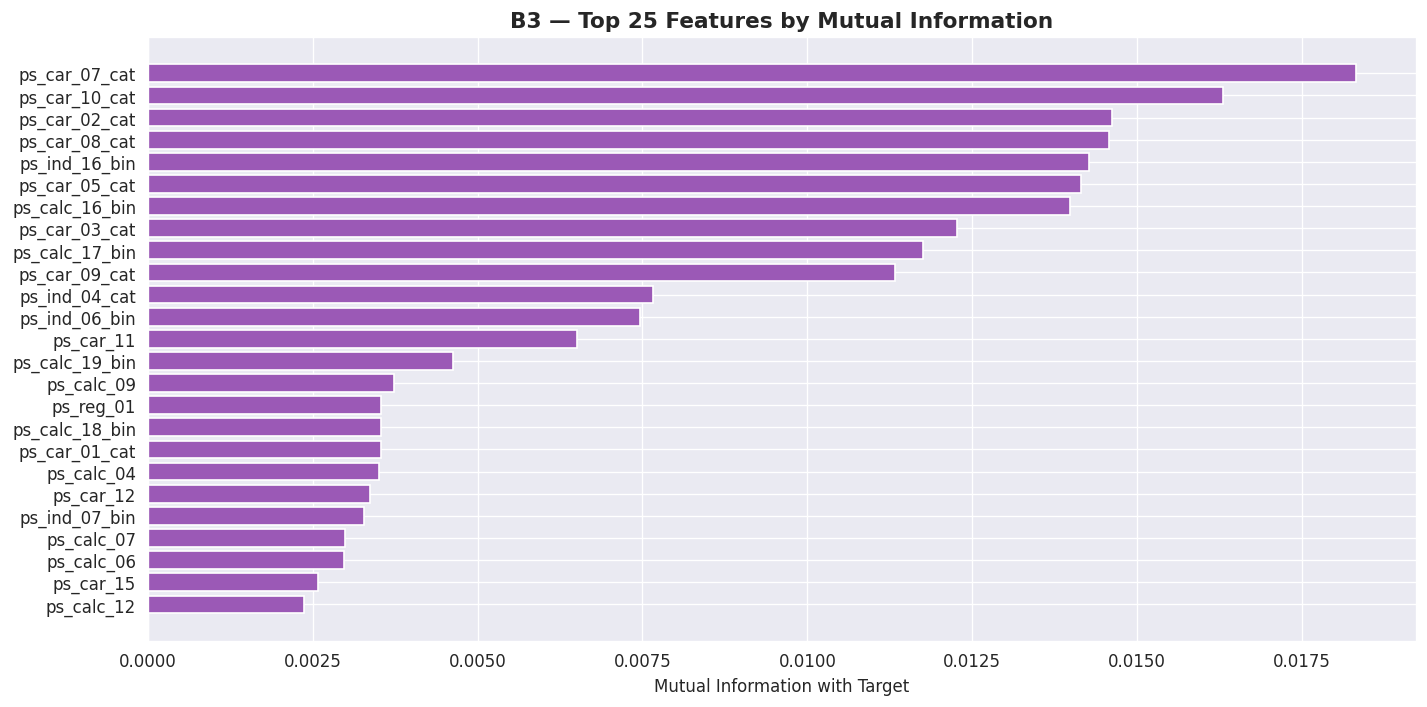

In [38]:
# ── Mutual Information with Target ───────────────────────────────────
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42, n_neighbors=5)
mi_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_mi = mi_series.head(25)
ax.barh(top_mi.index[::-1], top_mi.values[::-1], color='#9b59b6', edgecolor='white')
ax.set_xlabel('Mutual Information with Target')
ax.set_title('B3 — Top 25 Features by Mutual Information', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('B3_mutual_information.png', bbox_inches='tight')
plt.show()

In [39]:
# ── Train LightGBM for SHAP Analysis ────────────────────────────────
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2,
                                             stratify=y, random_state=42)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_jobs': -1
}

dtrain = lgb.Dataset(X_tr, label=y_tr)
dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

model_b3 = lgb.train(
    lgb_params, dtrain,
    num_boost_round=500,
    valid_sets=[dval],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)
print('LightGBM trained ✓')

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.62143
Early stopping, best iteration is:
[64]	valid_0's auc: 0.624989
LightGBM trained ✓


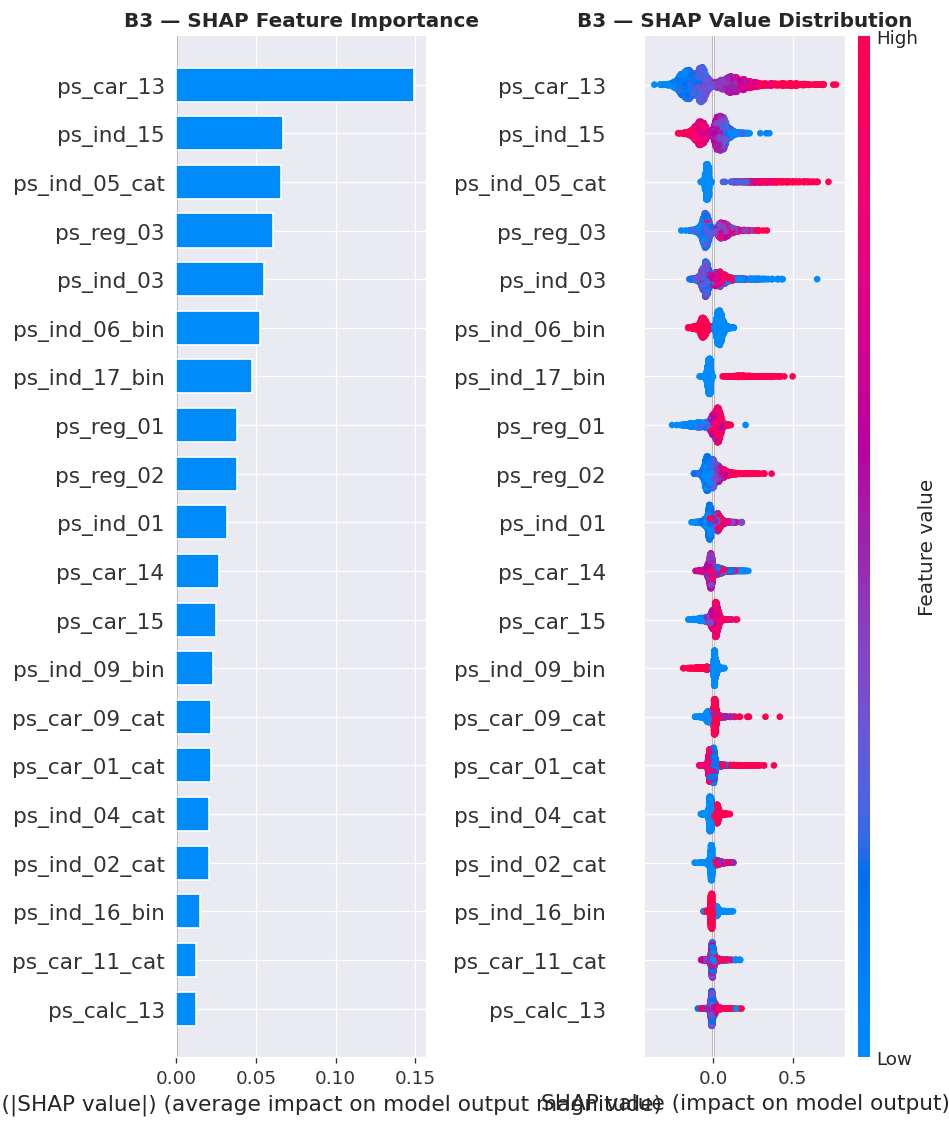

In [40]:
# ── SHAP Feature Importance ──────────────────────────────────────────
explainer = shap.TreeExplainer(model_b3)
# Use a subsample for speed
X_shap = X_val.iloc[:3000]
shap_values = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=20)
axes[0].set_title('B3 — SHAP Feature Importance', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
axes[1].set_title('B3 — SHAP Value Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('B3_shap_importance.png', bbox_inches='tight')
plt.show()

In [41]:
# ── SHAP Interaction Values (top features) ───────────────────────────
# Get top 10 features by SHAP importance
shap_abs_mean = np.abs(shap_values).mean(axis=0)
top10_idx = np.argsort(shap_abs_mean)[::-1][:10]
top10_feats = [features[i] for i in top10_idx]
print('Top 10 features by SHAP:', top10_feats)

# Pairwise interaction: AUC lift from feature products
from sklearn.metrics import roc_auc_score

base_auc = roc_auc_score(y_val, model_b3.predict(X_val))
print(f'\nBaseline AUC: {base_auc:.5f}')

interaction_results = []
X_val_aug = X_val.copy()

for f1, f2 in combinations(top10_feats[:6], 2):  # top 6 to keep compute manageable
    interaction_name = f'{f1}_x_{f2}'
    X_tr_aug  = X_tr.copy()
    X_tr_aug[interaction_name]  = X_tr[f1] * X_tr[f2]
    X_val_aug2 = X_val.copy()
    X_val_aug2[interaction_name] = X_val[f1] * X_val[f2]

    dt2 = lgb.Dataset(X_tr_aug, label=y_tr)
    dv2 = lgb.Dataset(X_val_aug2, label=y_val, reference=dt2)
    m2  = lgb.train(lgb_params, dt2, num_boost_round=200,
                    valid_sets=[dv2],
                    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(9999)])
    auc2 = roc_auc_score(y_val, m2.predict(X_val_aug2))
    interaction_results.append({'interaction': interaction_name, 'auc': auc2, 'lift': auc2 - base_auc})

int_df = pd.DataFrame(interaction_results).sort_values('lift', ascending=False)
print('\nTop interactions by AUC lift:')
print(int_df.to_string(index=False))

Top 10 features by SHAP: ['ps_car_13', 'ps_ind_15', 'ps_ind_05_cat', 'ps_reg_03', 'ps_ind_03', 'ps_ind_06_bin', 'ps_ind_17_bin', 'ps_reg_01', 'ps_reg_02', 'ps_ind_01']

Baseline AUC: 0.62499
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[67]	valid_0's auc: 0.63183
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[62]	valid_0's auc: 0.626285
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[83]	valid_0's auc: 0.630704
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[68]	valid_0's auc: 0.622942
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[56]	valid_0's auc: 0.624369
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[58]	valid_0's auc: 0.623225
Training until validation scores don't improve for 30 rounds

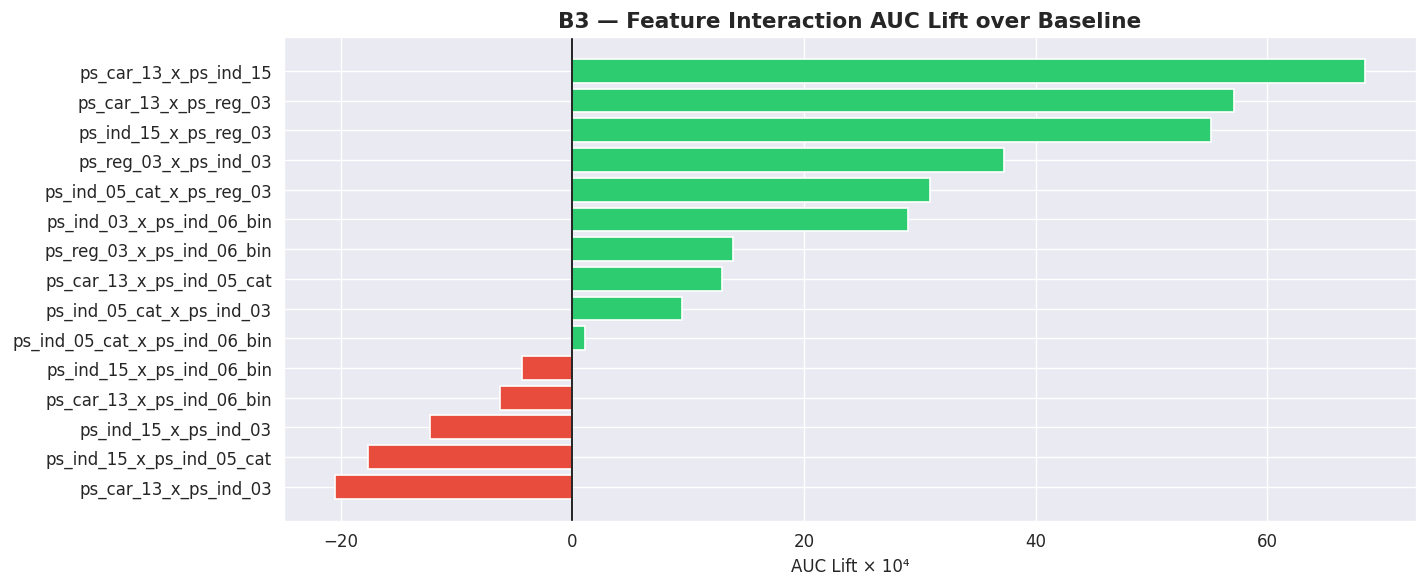

In [42]:
# ── Plot Interaction Results ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in int_df['lift']]
ax.barh(int_df['interaction'][::-1], int_df['lift'][::-1] * 10000,
        color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('AUC Lift × 10⁴')
ax.set_title('B3 — Feature Interaction AUC Lift over Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('B3_interaction_lift.png', bbox_inches='tight')
plt.show()

## B4 — Statistical Structure and Data Generation


### Pipeline Summary

**Goal:** Model the joint distribution of mixed-type driver features (binary, categorical, continuous) and reproduce the observed data-generating process.

**Proposed approach — CTGAN (Conditional Tabular GAN):**

1. **Preprocessing:** Convert -1 → NaN, apply mode/median imputation. Label-encode categoricals.
2. **Model:** Use `ctgan` library — designed for tabular data with mixed types.
   - Mode-specific normalization for continuous features.
   - Conditional vector ensures minority class (claim=1) is sampled faithfully.
3. **Training:** Fit CTGAN on training data. Monitor FID-like score (Wasserstein distance between real/synthetic marginals).
4. **Validation:**
   - Statistical test: KS-test per feature (real vs synthetic distributions).
   - Classifier test: Train a model to distinguish real vs synthetic — AUC near 0.5 means good synthesis.
   - Downstream test: Train a claim predictor on synthetic data, evaluate on real test set.
5. **Alternative:** Gaussian Copula model — fit marginals per feature, then model correlations via copula. Simpler and interpretable.
6. **Use cases:** Data augmentation for minority class, privacy-preserving data sharing, stress-testing models.